In [1]:
# librerias
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [34]:
# directorios

# Testing

En este cuaderno se realiza la **prueba definitiva** del modelo entrenado con máscaras segmentadas de lesiones cutáneas.  
El modelo utilizado es el **MelanomaNet**, que ha demostrado ofrecer el mejor rendimiento durante la fase de entrenamiento y validación cuando se alimenta con **máscaras que representan únicamente la región de la lesión (sin fondo ni piel circundante)**.

El propósito de este experimento es **evaluar la capacidad generalizadora del modelo** utilizando un **conjunto de máscaras externas**, es decir, imágenes **no vistas durante el entrenamiento**, que hemos obetenidos del dataset público *ISIC* (https://gallery.isic-archive.com/#!/topWithHeader/onlyHeaderTop/gallery)

**Carga Modelo**

In [2]:
model_path = "./models/MelanomaNet.keras"
model = tf.keras.models.load_model(model_path)
print(" Modelo cargado correctamente")

2025-10-17 11:30:47.325988: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-10-17 11:30:47.326024: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-10-17 11:30:47.326028: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-10-17 11:30:47.326246: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-17 11:30:47.326261: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


 Modelo cargado correctamente


In [3]:
model.summary()

Model: "MelanomaNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,356,232 (295.09 MB)

 Trainable params: 25,785,090 (98.36 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 51,570,182 (196.72 MB)

**Carga y Normalizado de Imágenes***

In [4]:
base_dir = "./data/lesions/external"
mask_dirs = {
    "Benign": os.path.join(base_dir, "Benign"),
    "Malignant": os.path.join(base_dir, "Malignant"),
}


In [5]:
img_size = (224, 224)   
class_names = ["Benign", "Malignant"]

def load_and_preprocess_mask(img_path):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0  # normalizar
    return np.expand_dims(img_array, axis=0)


In [6]:
file_paths, y_true, y_pred, y_prob = [], [], [], []

for label, folder in mask_dirs.items():
    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder, fname)
            img_batch = load_and_preprocess_mask(img_path)
            
            pred = model.predict(img_batch, verbose=0)[0]
            pred_class = np.argmax(pred)
            prob = np.max(pred)
            
            file_paths.append(img_path)
            y_true.append(class_names.index(label))
            y_pred.append(pred_class)
            y_prob.append(prob)

2025-10-17 11:30:56.197054: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


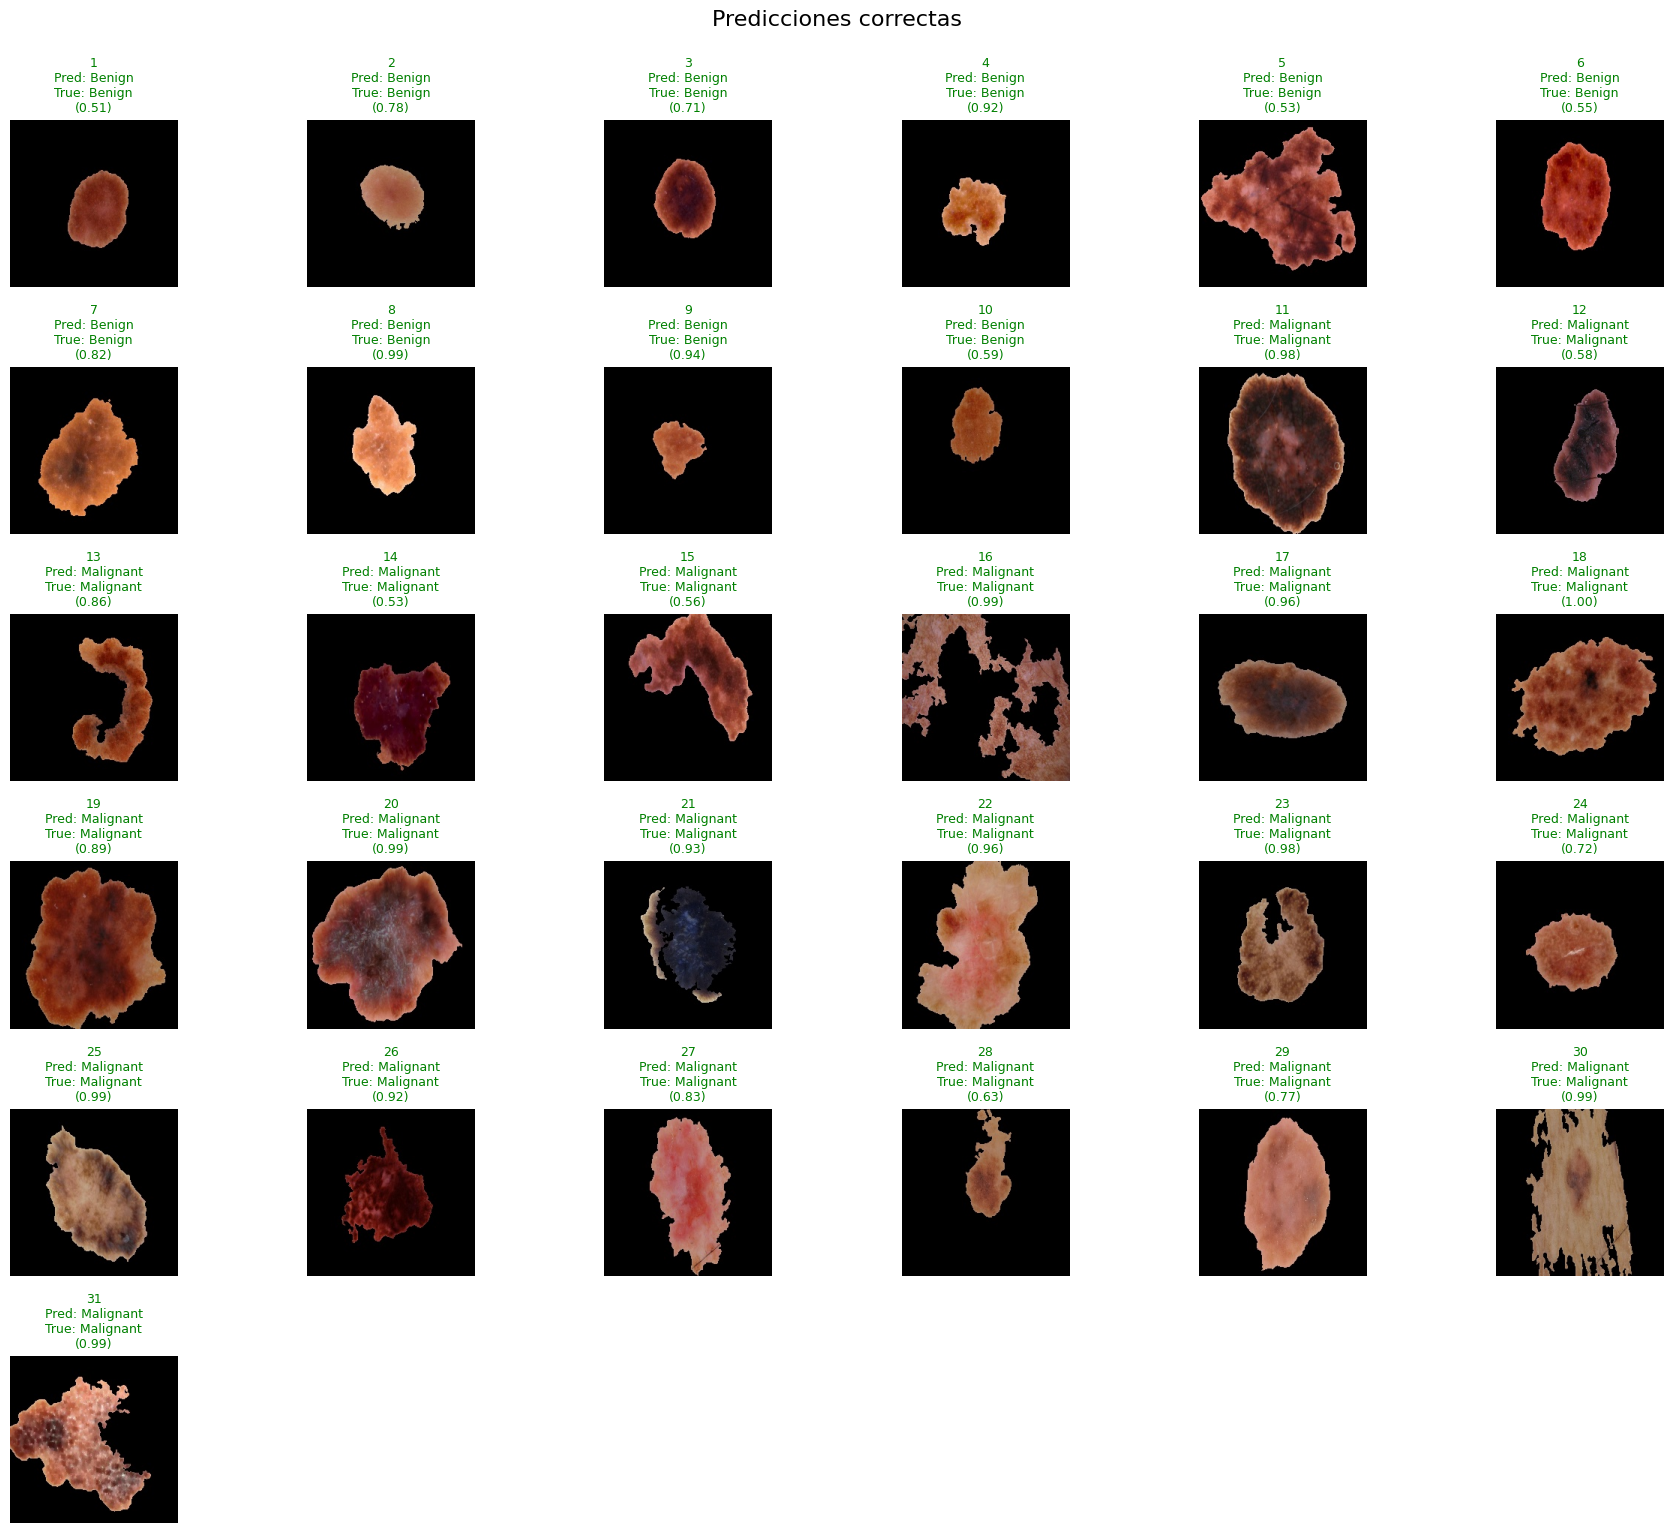

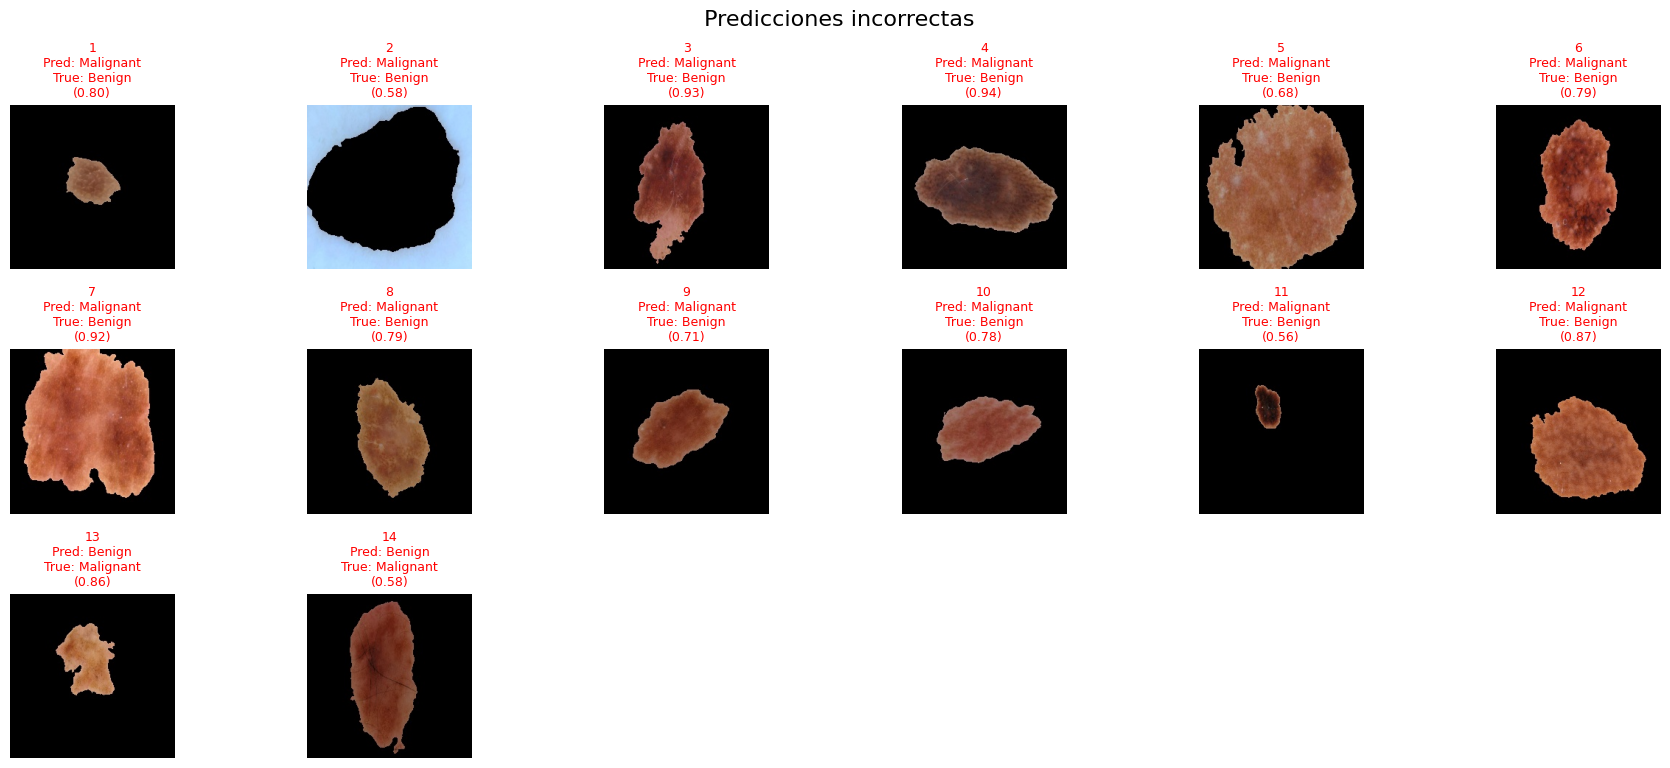

In [7]:
correct_idx = [i for i in range(len(y_true)) if y_true[i] == y_pred[i]]
incorrect_idx = [i for i in range(len(y_true)) if y_true[i] != y_pred[i]]

def plot_grid(indices, title, color): 
    N = len(indices)
    cols = 6
    rows = int(np.ceil(N / cols))
    plt.figure(figsize=(18, rows * 2.5))
    
    for j, i in enumerate(indices):
        img = image.load_img(file_paths[i])
        plt.subplot(rows, cols, j + 1)
        plt.imshow(img)
        
        true_label = class_names[y_true[i]]
        pred_label = class_names[y_pred[i]]
        prob = y_prob[i]
        
        plt.title(f"{j+1}\nPred: {pred_label}\nTrue: {true_label}\n({prob:.2f})",
                  color=color, fontsize=9)
        plt.axis('off')

    plt.tight_layout(pad=1.2)
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.show()

# --- 6. Visualizar ---
plot_grid(correct_idx, "Predicciones correctas", color="green")
plot_grid(incorrect_idx, " Predicciones incorrectas", color="red")


Precisión total: 31/45 = 68.89%


<Figure size 500x500 with 0 Axes>

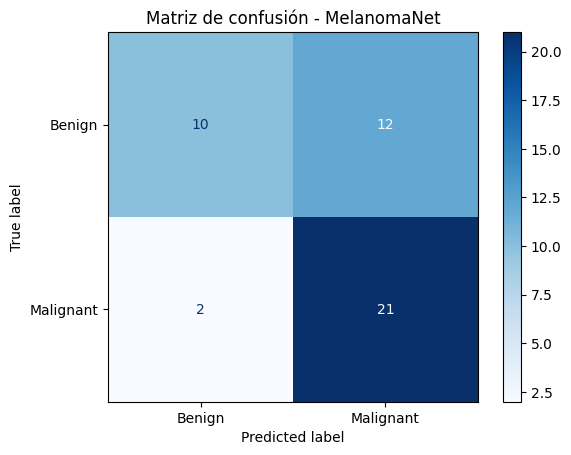

In [8]:
correct = sum(p == t for p, t in zip(y_pred, y_true))
total = len(y_true)
print(f"Precisión total: {correct}/{total} = {correct/total:.2%}")

# --- 7. Matriz de confusión ---
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(5,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión - MelanomaNet")
plt.show()

In [28]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output],
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8
    return heatmap


In [29]:
def display_gradcam(img_path, heatmap, alpha=0.45):
    img = image.load_img(img_path)
    img = image.img_to_array(img)
    heatmap = np.uint8(255 * heatmap)

    # Redimensionar mapa
    heatmap = np.expand_dims(heatmap, axis=-1)
    heatmap = tf.image.resize(heatmap, (img.shape[0], img.shape[1])).numpy().astype("uint8")
    heatmap = np.squeeze(heatmap)

    cmap = plt.get_cmap("jet")
    colored_heatmap = cmap(heatmap)
    colored_heatmap = np.delete(colored_heatmap, 3, 2)  # eliminar canal alpha

    superimposed_img = colored_heatmap * alpha + img / 255.0
    superimposed_img /= np.max(superimposed_img)
    plt.imshow(superimposed_img)
    plt.axis("off")